# Taller 2 - Red de Monitoreo de Calidad del Aire de Bogota.
http://rmcab.ambientebogota.gov.co/Report/stationreport

## Integrantes:
### Nombre: Christian Camilo Rosero Rodriguez, cod: 2503026-7729 
### Nombre: Carlos David Rojas Lozano, cod: 2503497-7729

## Descripción de los datos 

## 1. Cargar Librerias
***

In [12]:
# Carga las librerias necesarias

import pandas as pd
from os import walk
import os, re   #expresiones regulares

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Cargar Datos

In [13]:
#dataframe nombrado "df"
#Se usará el conjunto de datos "dataset_with_geo_missing" creado en el Taller 1, 
#este conjunto de datos, se caracteriza por no tener algunos valores.
 

 # carga el conjunto de datos ../Taller1/data/dataset_with_geo_missing.csv

path = '../Taller1/data/dataset_with_geo_missing.csv'
df = pd.read_csv(path)
df.head()

,PM10,PM2.5,NO,NO2,NOX,CO,OZONO,Station,DateTime,Status,Latitud,Longitud,Localidad,Nombre,month,day_week,day_month,hour
0,52.6,37.0,53.384,3.428,56.817,NaN,NaN,7MA,2021-01-01 01:00:00,True,4.645117,-74.061503,Chapinero,movil_7ma,1,4,1,1
1,77.9,61.0,49.105,3.420,52.525,NaN,NaN,7MA,2021-01-01 02:00:00,True,4.645117,-74.061503,Chapinero,movil_7ma,1,4,1,2
2,58.5,48.0,47.284,4.062,51.346,NaN,NaN,7MA,2021-01-01 03:00:00,True,4.645117,-74.061503,Chapinero,movil_7ma,1,4,1,3
3,57.2,44.0,46.059,3.606,49.664,NaN,NaN,7MA,2021-01-01 04:00:00,True,4.645117,-74.061503,Chapinero,movil_7ma,1,4,1,4
4,53.5,39.0,39.851,1.625,41.475,NaN,NaN,7MA,2021-01-01 05:00:00,True,4.645117,-74.061503,Chapinero,movil_7ma,1,4,1,5


## 3: Explorar datos
*** 

###  3.1 Estadisticas 
***
Resumen: 
- Identificar nombre de las columnas
- Número de columnas y filas 
- Tamaño del conjunto de datos
- Tipos de datos
- Porcentajes de valores
- Correlaciones de variables
- Valores nulos


In [14]:
# Estadisticas basicas del conjunto de datos 
df.describe()

,PM10,PM2.5,NO,NO2,NOX,CO,OZONO,Latitud,Longitud,month,day_week,day_month,hour
count,146426.000000,151128.000000,138776.000000,138778.000000,138772.000000,135202.000000,134308.000000,166440.000000,166440.000000,166440.000000,166440.000000,166440.000000,166440.000000
mean,31.978378,15.323489,18.616861,14.979247,33.590300,0.691233,11.782188,4.653331,-74.104733,6.526027,3.002740,15.720548,12.500000
std,22.835375,12.467040,26.932382,9.233824,30.056319,0.574689,10.133101,0.068116,0.039154,3.447862,1.997948,8.796273,6.922207
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.532097,-74.166272,1.000000,0.000000,1.000000,1.000000
25%,15.800000,6.000000,3.169000,7.515000,13.109000,0.324885,3.458000,4.595958,-74.143714,4.000000,1.000000,8.000000,6.750000
50%,26.700000,12.000000,7.759000,13.742000,24.259000,0.520580,9.564000,4.645117,-74.114869,7.000000,3.000000,16.000000,12.500000
75%,42.300000,21.600000,21.532000,20.626000,43.472250,0.862195,17.518250,4.710381,-74.069472,10.000000,5.000000,23.000000,18.250000
max,326.200000,188.000000,341.104000,92.256000,361.341000,12.025010,88.182000,4.783614,-74.030414,12.000000,6.000000,31.000000,24.000000


In [15]:
#Descripción del conjunto de datos: 166440 observaciones y 10 caracteristicas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166440 entries, 0 to 166439
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   PM10       146426 non-null  float64
 1   PM2.5      151128 non-null  float64
 2   NO         138776 non-null  float64
 3   NO2        138778 non-null  float64
 4   NOX        138772 non-null  float64
 5   CO         135202 non-null  float64
 6   OZONO      134308 non-null  float64
 7   Station    166440 non-null  object 
 8   DateTime   166440 non-null  object 
 9   Status     166440 non-null  bool   
 10  Latitud    166440 non-null  float64
 11  Longitud   166440 non-null  float64
 12  Localidad  166440 non-null  object 
 13  Nombre     166440 non-null  object 
 14  month      166440 non-null  int64  
 15  day_week   166440 non-null  int64  
 16  day_month  166440 non-null  int64  
 17  hour       166440 non-null  int64  
dtypes: bool(1), float64(9), int64(4), object(4)
memory usage: 21.7+ 

In [16]:
# Comprobar el número de Filas y Columnas 
print("Número de  Filas: ", len(df))
print("Número de Columnas ", + len(df.columns))

#Comprobar el tipo de datos en las características
print(df.dtypes)

Número de  Filas:  166440
Número de Columnas  18
PM10         float64
PM2.5        float64
NO           float64
NO2          float64
NOX          float64
CO           float64
OZONO        float64
Station       object
DateTime      object
Status          bool
Latitud      float64
Longitud     float64
Localidad     object
Nombre        object
month          int64
day_week       int64
day_month      int64
hour           int64
dtype: object


In [17]:
#Comprobar si hay valores nulos true o false
df.isnull().values.any()

True

In [18]:
# Esta celda eliminará todas las filas que tienen valores nulos
df = df.dropna()
df.isnull().sum()

PM10         0
PM2.5        0
NO           0
NO2          0
NOX          0
CO           0
OZONO        0
Station      0
DateTime     0
Status       0
Latitud      0
Longitud     0
Localidad    0
Nombre       0
month        0
day_week     0
day_month    0
hour         0
dtype: int64

In [19]:
# Resumen de una variable (False V.S. True) en la variable Status
Status_Summary = df.groupby('Status')

In [20]:
Status_Summary.mean()

TypeError: agg function failed [how->mean,dtype->object]

In [21]:
#Filtrar datos por columnas
df.iloc[:,[0,1,2,3]]

,PM10,PM2.5,NO,NO2
13870,19.7,4.7,5.582,18.818
13871,14.9,4.4,1.005,18.702
13872,10.9,4.3,2.750,15.919
13873,12.6,3.9,2.825,15.293
13874,13.9,3.2,1.876,14.139
...,...,...,...,...
166435,25.3,18.0,1.404,3.688
166436,27.7,15.0,0.244,3.205
166437,25.3,20.0,0.880,4.648
166438,24.0,17.0,1.697,8.596


####  3.1.1 Correlación
***

Resumen:


- Hay una correlación **positiva(+) a 1** o **negativa(-) a -1** hay una correlacion fuerte. La aproximación a 0 es mas debil la relacion lineal  

In [22]:
#Convertir columnas categóricas a numéricas
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = df[col].astype('category').cat.codes

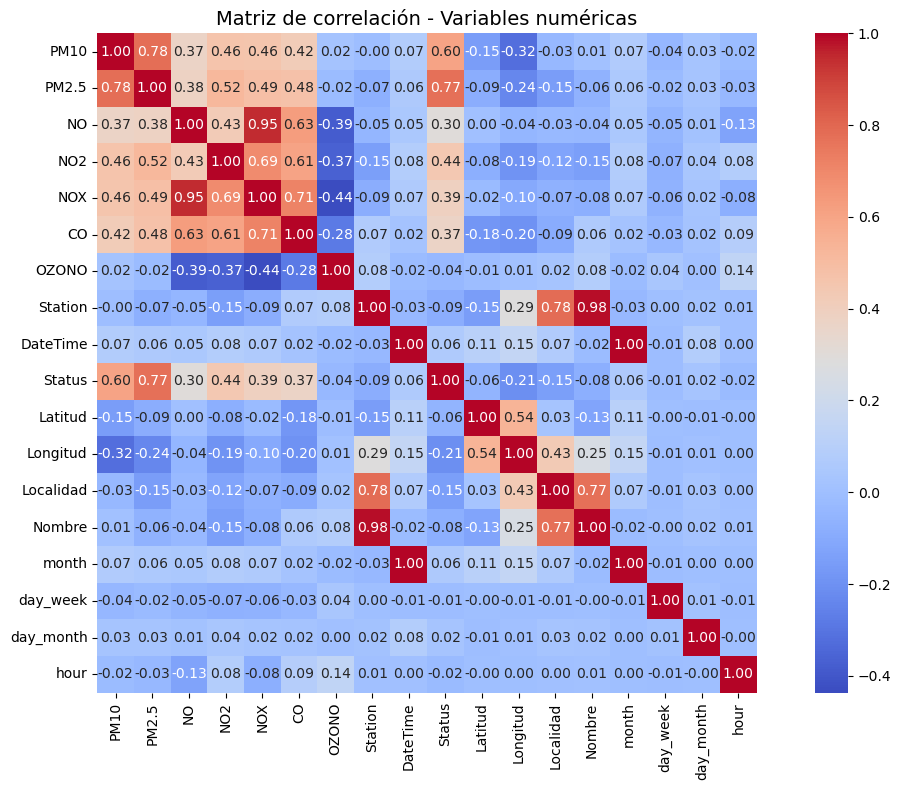

In [23]:
#Matriz de correlación
corr = df.corr()

# Configurar el tamaño de la figura
plt.figure(figsize=(12, 8))

# Dibujar heatmap
sns.heatmap(
    corr,
    annot=True,        # mostrar valores numéricos
    fmt=".2f",         # formato con 2 decimales
    cmap="coolwarm",   # paleta de colores
    cbar=True,         # barra de color
    square=True        # celdas cuadradas
)

plt.title("Matriz de correlación - Variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

###  3.2 Gráficos de distribución 


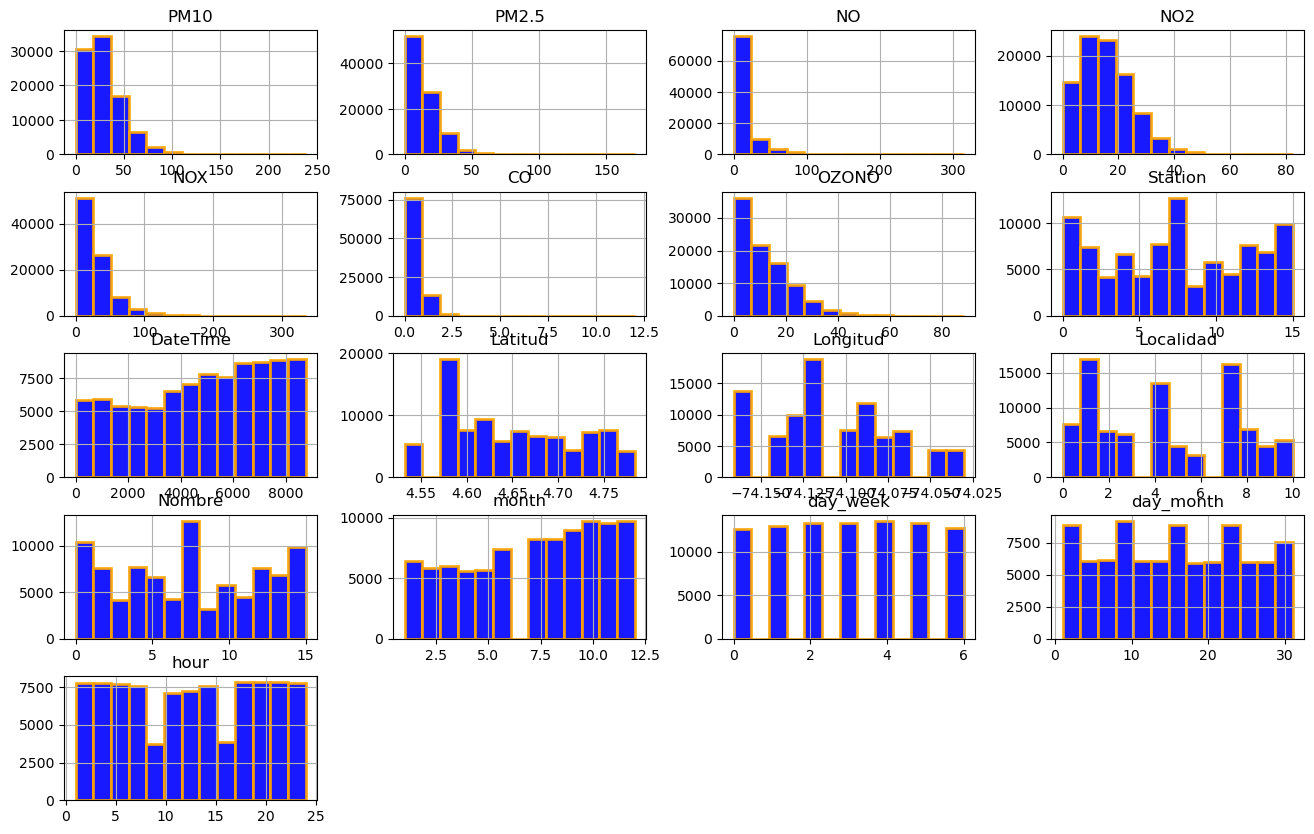

In [24]:
#hist es un grafico (pandas) de distribucion de  datos.
#este grafico nos sirve para identificar cuales son las variables numericas y su frencuencia. 

df.hist(figsize=(16,10),facecolor='blue', alpha=0.9, bins=13, edgecolor='orange', linewidth=2)
plt.show()

/tmp/ipykernel_12157/1448057234.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.PM10, kde=False, color="g", ax=axes[0]).set_title('PM10')
/tmp/ipykernel_12157/1448057234.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Status, kde=False, color="r", ax=axes[1]).set_title('Status')
/t

Text(0.5, 1.0, 'NOX')

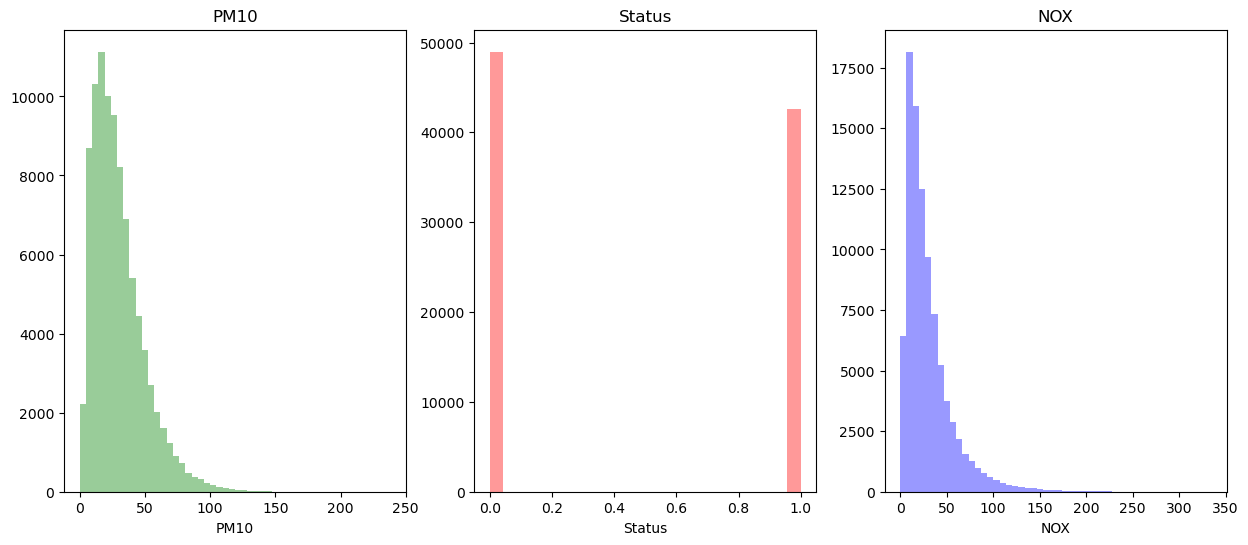

In [25]:
#otra forma de ver la distribucion de los datos
# Uso de Libreria Seaborn (sna) para poner multiples graficos de distribución  
f, axes = plt.subplots(ncols=3, figsize=(15, 6))

#variable PM10
sns.distplot(df.PM10, kde=False, color="g", ax=axes[0]).set_title('PM10')

#variable PM10
sns.distplot(df.Status, kde=False, color="r", ax=axes[1]).set_title('Status')

#variable NOX
sns.distplot(df.NOX, kde=False, color="b", ax=axes[2]).set_title('NOX')

###  3.3 Gráfico de barras


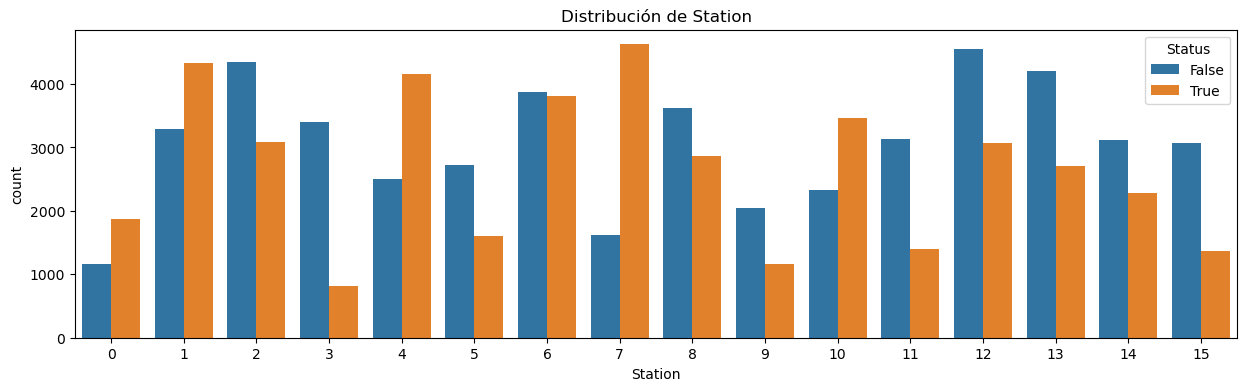

In [26]:
#ditribucion por estacion 
f, ax = plt.subplots(figsize=(15, 4))
sns.countplot(x="Station", hue='Status', data=df).set_title('Distribución de Station');

(array([   0., 1000., 2000., 3000., 4000., 5000., 6000., 7000., 8000.,
        9000.]),
 [Text(0.0, 0, '0'),
  Text(1000.0, 0, '1000'),
  Text(2000.0, 0, '2000'),
  Text(3000.0, 0, '3000'),
  Text(4000.0, 0, '4000'),
  Text(5000.0, 0, '5000'),
  Text(6000.0, 0, '6000'),
  Text(7000.0, 0, '7000'),
  Text(8000.0, 0, '8000'),
  Text(9000.0, 0, '9000')])

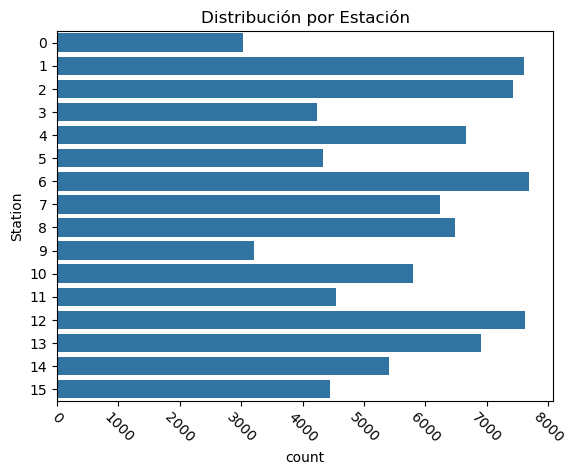

In [27]:
# Types of colors
color_types = ['#78C850','#F08030','#6890F0','#A8B820','#A8A878','#A040A0','#F8D030',  
                '#E0C068','#EE99AC','#C03028','#F85888','#B8A038','#705898','#98D8D8','#7038F8' ,'#FFFFF']

# Count Plot (a.k.a. Bar Plot)
sns.countplot(y='Station', data=df).set_title('Distribución por Estación');
 
# Rotate x-labels
plt.xticks(rotation=-45)

###  3.4 Gráficos de Cajas


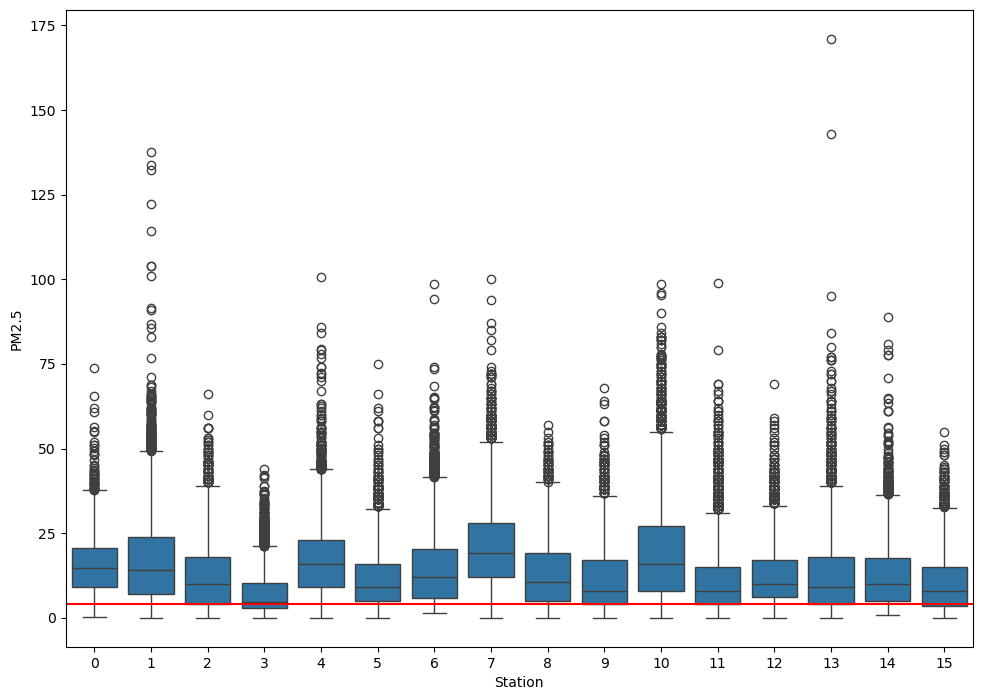

In [28]:
import seaborn as sns

a4_dims = (11.7, 8.27)
fig, ax = plt.subplots(figsize=a4_dims)

sns.boxplot(x="Station", y="PM2.5",  data=df)
valh=4
plt.axhline(valh, color='red')

Hemos revisado la información de ded dataset "calidad del aire", donde es importante la estación que mide la calidad del aire, sin embargo, no tenemos donde esta ubicada. 

Ahora vamos a cargar un nuevo dataset, que contiene la infromación de la ubicación (Latitud, Longitud) de cada estación.

## 4. Tecnicas para solucionar valores perdidos y anomalias en un dataset

In [31]:
 # carga el conjunto de datos ../Taller1/data/dataset_with_geo_missing.csv
path = '../Taller1/data/dataset_with_geo_missing.csv'
df = pd.read_csv(path)
df.head()

,PM10,PM2.5,NO,NO2,NOX,CO,OZONO,Station,DateTime,Status,Latitud,Longitud,Localidad,Nombre,month,day_week,day_month,hour
0,52.6,37.0,53.384,3.428,56.817,NaN,NaN,7MA,2021-01-01 01:00:00,True,4.645117,-74.061503,Chapinero,movil_7ma,1,4,1,1
1,77.9,61.0,49.105,3.420,52.525,NaN,NaN,7MA,2021-01-01 02:00:00,True,4.645117,-74.061503,Chapinero,movil_7ma,1,4,1,2
2,58.5,48.0,47.284,4.062,51.346,NaN,NaN,7MA,2021-01-01 03:00:00,True,4.645117,-74.061503,Chapinero,movil_7ma,1,4,1,3
3,57.2,44.0,46.059,3.606,49.664,NaN,NaN,7MA,2021-01-01 04:00:00,True,4.645117,-74.061503,Chapinero,movil_7ma,1,4,1,4
4,53.5,39.0,39.851,1.625,41.475,NaN,NaN,7MA,2021-01-01 05:00:00,True,4.645117,-74.061503,Chapinero,movil_7ma,1,4,1,5


In [37]:
#Contar valores nulos por columnas
df.isnull().sum()

PM10             0
PM2.5        15312
NO           27664
NO2          27662
NOX          27668
CO           31238
OZONO        32132
Station          0
DateTime         0
Status           0
Latitud          0
Longitud         0
Localidad        0
Nombre           0
month            0
day_week         0
day_month        0
hour             0
dtype: int64

### 4.1 Completar con la media, mediana o desviación estándar

In [40]:
#Para todo el conjunto de datos 
df_1 = df.fillna(df.std(numeric_only=True))
df_1.iloc[0]


#Para una sola columna

#df_1 = df['PM10'].fillna((df['PM10'].std()), inplace=True)


PM10                        52.6
PM2.5                       37.0
NO                        53.384
NO2                        3.428
NOX                       56.817
CO                      0.574689
OZONO                  10.133101
Station                      7MA
DateTime     2021-01-01 01:00:00
Status                      True
Latitud                 4.645117
Longitud              -74.061503
Localidad              Chapinero
Nombre                 movil_7ma
month                          1
day_week                       4
day_month                      1
hour                           1
Name: 0, dtype: object

In [42]:
df_1.isnull().sum()

PM10         0
PM2.5        0
NO           0
NO2          0
NOX          0
CO           0
OZONO        0
Station      0
DateTime     0
Status       0
Latitud      0
Longitud     0
Localidad    0
Nombre       0
month        0
day_week     0
day_month    0
hour         0
dtype: int64

### 4.2 Completar con valor predeterminada 

In [43]:
df_2 = df.fillna(25)
df_2.iloc[0]

PM10                        52.6
PM2.5                       37.0
NO                        53.384
NO2                        3.428
NOX                       56.817
CO                          25.0
OZONO                       25.0
Station                      7MA
DateTime     2021-01-01 01:00:00
Status                      True
Latitud                 4.645117
Longitud              -74.061503
Localidad              Chapinero
Nombre                 movil_7ma
month                          1
day_week                       4
day_month                      1
hour                           1
Name: 0, dtype: object

In [44]:
df_2.isnull().sum()

PM10         0
PM2.5        0
NO           0
NO2          0
NOX          0
CO           0
OZONO        0
Station      0
DateTime     0
Status       0
Latitud      0
Longitud     0
Localidad    0
Nombre       0
month        0
day_week     0
day_month    0
hour         0
dtype: int64

### 4.3 Eliminar NaN

In [46]:
# Filas que contienen al menos un NaN
nan_rows = df[df.isnull().any(axis=1)]

#Elinina todas las filas que tengan NaN
df_3 = nan_rows.dropna()

In [47]:
df_3.isnull().sum()

PM10         0
PM2.5        0
NO           0
NO2          0
NOX          0
CO           0
OZONO        0
Station      0
DateTime     0
Status       0
Latitud      0
Longitud     0
Localidad    0
Nombre       0
month        0
day_week     0
day_month    0
hour         0
dtype: int64